In [ ]:
# Healthcare Analytics – Doctor Visits Analysis

This project analyzes doctor visit data to understand healthcare utilization patterns based on demographics, income, illness, health conditions, and chronic diseases.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
df = pd.read_csv("1776250375-P2-Healthcare Analytics for Doctor Visits.csv")

df.head(10)

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no
5,6,1,female,0.19,0.35,5,1,9,no,no,no,yes,no
6,7,1,female,0.19,0.55,4,0,2,no,no,no,no,no
7,8,1,female,0.19,0.15,3,0,6,no,no,no,no,no
8,9,1,female,0.19,0.65,2,0,5,yes,no,no,no,no
9,10,1,male,0.19,0.15,1,0,0,yes,no,no,no,no


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5190
Number of columns: 13


In [7]:
print(df.columns.tolist())

['Unnamed: 0', 'visits', 'gender', 'age', 'income', 'illness', 'reduced', 'health', 'private', 'freepoor', 'freerepat', 'nchronic', 'lchronic']


In [ ]:
## Dataset Variables

- visits: Number of doctor visits
- gender: Patient gender
- age: Age category/code
- income: Income level/code
- illness: Number/severity category of illness
- reduced: Number of days activity was reduced due to illness
- health: Health condition/health score
- private: Private health insurance status
- freepoor: Free healthcare coverage for low-income individuals
- freerepat: Free/repatriation healthcare coverage
- nchronic: Presence of chronic condition
- lchronic: Presence of another chronic condition

In [8]:
df.dtypes

Unnamed: 0      int64
visits          int64
gender         object
age           float64
income        float64
illness         int64
reduced         int64
health          int64
private        object
freepoor       object
freerepat      object
nchronic       object
lchronic       object
dtype: object

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB


In [10]:
df.isnull().sum()

Unnamed: 0    0
visits        0
gender        0
age           0
income        0
illness       0
reduced       0
health        0
private       0
freepoor      0
freerepat     0
nchronic      0
lchronic      0
dtype: int64

In [11]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [12]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [23]:
df.describe()

,visits,age,income,illness,reduced,health
count,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000
mean,0.301734,0.406385,0.583160,1.431985,0.861850,1.217534
std,0.798134,0.204782,0.368907,1.384152,2.887628,2.124266
min,0.000000,0.190000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.220000,0.250000,0.000000,0.000000,0.000000
50%,0.000000,0.320000,0.550000,1.000000,0.000000,0.000000
75%,0.000000,0.620000,0.900000,2.000000,0.000000,2.000000
max,9.000000,0.720000,1.500000,5.000000,14.000000,12.000000


In [24]:
df.describe(include="object")

,gender,private,freepoor,freerepat,nchronic,lchronic
count,5190,5190,5190,5190,5190,5190
unique,2,2,2,2,2,2
top,female,no,no,no,no,no
freq,2702,2892,4968,4099,3098,4585


In [ ]:
#check unique value

In [25]:
for column in df.columns:
    print("\n", column)
    print(df[column].unique())


 visits
[1 2 3 4 8 5 7 6 9 0]

 gender
['female' 'male']

 age
[0.19 0.22 0.27 0.32 0.37 0.42 0.47 0.52 0.57 0.62 0.67 0.72]

 income
[0.55 0.45 0.9  0.15 0.35 0.65 0.25 0.   0.06 1.1  0.75 0.01 1.3  1.5 ]

 illness
[1 3 2 5 4 0]

 reduced
[ 4  2  0  5  1 13  7  3 14  6  8  9 10 12 11]

 health
[ 1  0  9  2  6  5  7 11  4 12  3 10  8]

 private
['yes' 'no']

 freepoor
['no' 'yes']

 freerepat
['no' 'yes']

 nchronic
['no' 'yes']

 lchronic
['no' 'yes']


In [ ]:
# DOCTOR VISIT DISTRIBUTION

In [26]:
df["visits"].value_counts().sort_index()

visits
0    4141
1     782
2     174
3      30
4      24
5       9
6      12
7      12
8       5
9       1
Name: count, dtype: int64

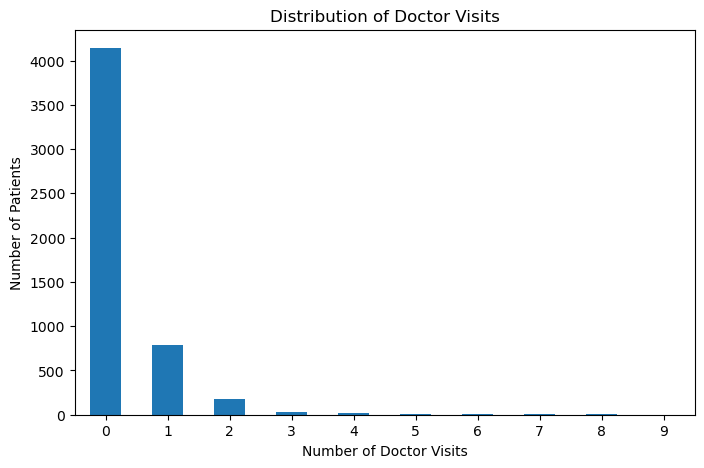

In [27]:
plt.figure(figsize=(8,5))

df["visits"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Doctor Visits")
plt.xlabel("Number of Doctor Visits")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)

plt.show()

In [ ]:
##What this tells us

The dataset is dominated by patients with 0 doctor visits, followed by patients with 1 visit.

This is an important finding because the distribution is highly concentrated toward zero.

In [ ]:
#CALCULATE AVERAGE

In [28]:
average_visits = df["visits"].mean()

print("Average doctor visits:", round(average_visits, 2))

Average doctor visits: 0.3


In [ ]:
#PATIENT WHO VISITED DOCTOR

In [30]:
df["visited_doctor"] = np.where(df["visits"] > 0, "Yes", "No")

In [31]:
df["visited_doctor"].value_counts()

visited_doctor
No     4141
Yes    1049
Name: count, dtype: int64

In [32]:
visit_percentage = df["visited_doctor"].value_counts(normalize=True) * 100

print(visit_percentage.round(2))

visited_doctor
No     79.79
Yes    20.21
Name: proportion, dtype: float64


In [ ]:
## Why this is useful

Instead of looking only at the number of visits, we can divide patients into:

visited doctor
did not visit doctor

This makes healthcare utilization analysis easier.

In [ ]:
# GENDER ANALYSIS

In [33]:
gender_visits = df.groupby("gender")["visits"].agg(
    ["count", "sum", "mean"]
)

gender_visits

,count,sum,mean
gender,,,
female,2702,978,0.361954
male,2488,588,0.236334


In [ ]:
# GENDER VISUALISATION

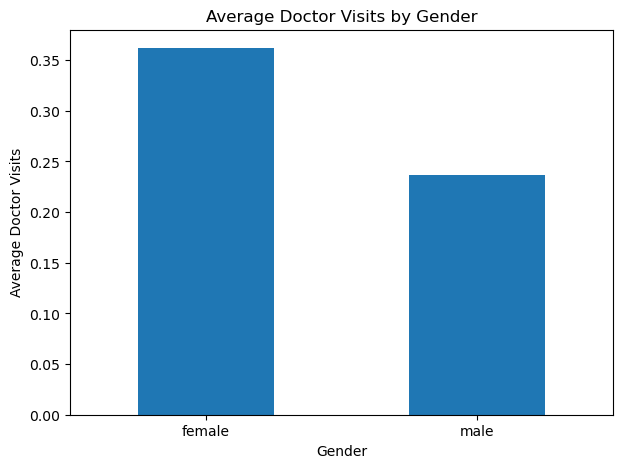

In [34]:
plt.figure(figsize=(7,5))

df.groupby("gender")["visits"].mean().plot(kind="bar")

plt.title("Average Doctor Visits by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Doctor Visits")
plt.xticks(rotation=0)

plt.show()

In [ ]:
# AGE CATEGORY ANALYSIS

In [35]:
age_analysis = df.groupby("age")["visits"].agg(
    ["count", "sum", "mean"]
)

age_analysis

,count,sum,mean
age,,,
0.19,752,160,0.212766
0.22,1213,244,0.201154
0.27,523,135,0.258126
0.32,301,73,0.242525
0.37,146,36,0.246575
0.42,126,40,0.317460
0.47,181,49,0.270718
0.52,222,92,0.414414
0.57,273,109,0.399267


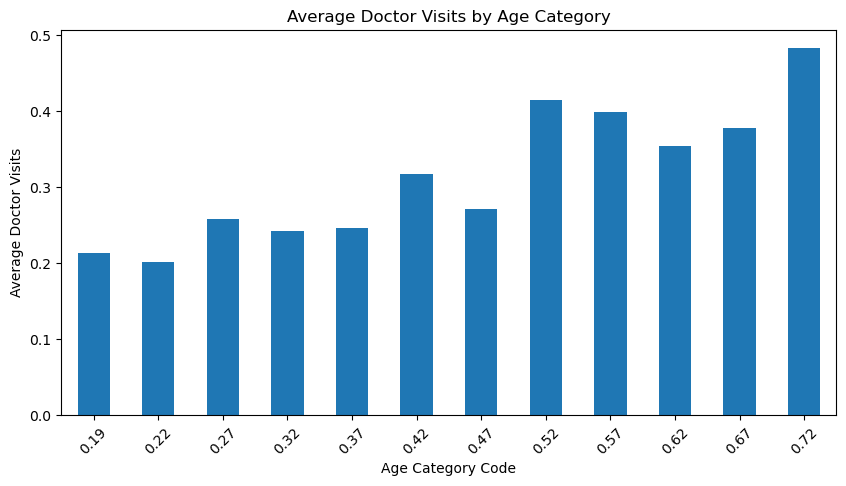

In [36]:
plt.figure(figsize=(10,5))

age_analysis["mean"].plot(kind="bar")

plt.title("Average Doctor Visits by Age Category")
plt.xlabel("Age Category Code")
plt.ylabel("Average Doctor Visits")
plt.xticks(rotation=45)

plt.show()

In [ ]:
# INCOME ANALYSIS

In [37]:
income_analysis = df.groupby("income")["visits"].agg(
    ["count", "sum", "mean"]
)

income_analysis

,count,sum,mean
income,,,
0.00,79,29,0.367089
0.01,35,17,0.485714
0.06,80,16,0.200000
0.15,249,87,0.349398
0.25,1195,503,0.420921
0.35,462,166,0.359307
0.45,400,122,0.305000
0.55,467,118,0.252677
0.65,455,112,0.246154


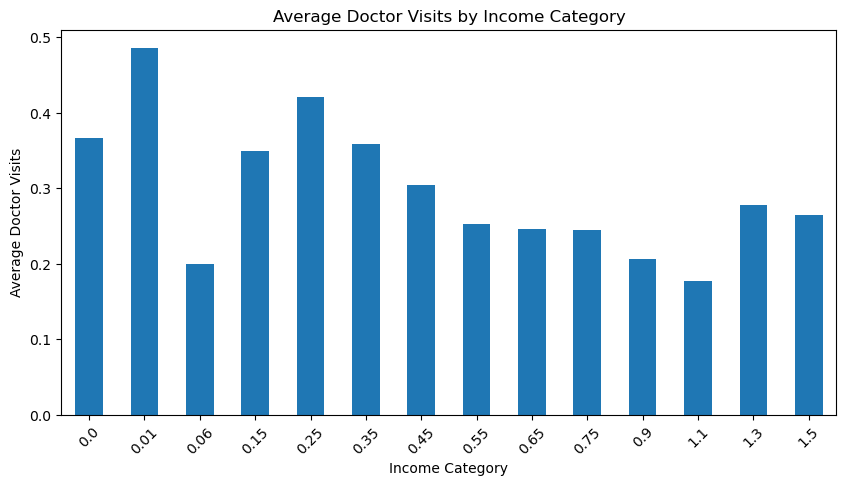

In [38]:
plt.figure(figsize=(10,5))

income_analysis["mean"].plot(kind="bar")

plt.title("Average Doctor Visits by Income Category")
plt.xlabel("Income Category")
plt.ylabel("Average Doctor Visits")
plt.xticks(rotation=45)

plt.show()

In [ ]:
# ILLNESS ANALYSIS

In [39]:
illness_analysis = df.groupby("illness")["visits"].agg(
    ["count", "sum", "mean"]
)

illness_analysis

,count,sum,mean
illness,,,
0,1554,122,0.078507
1,1638,484,0.295482
2,946,382,0.403805
3,542,228,0.420664
4,274,158,0.576642
5,236,192,0.813559


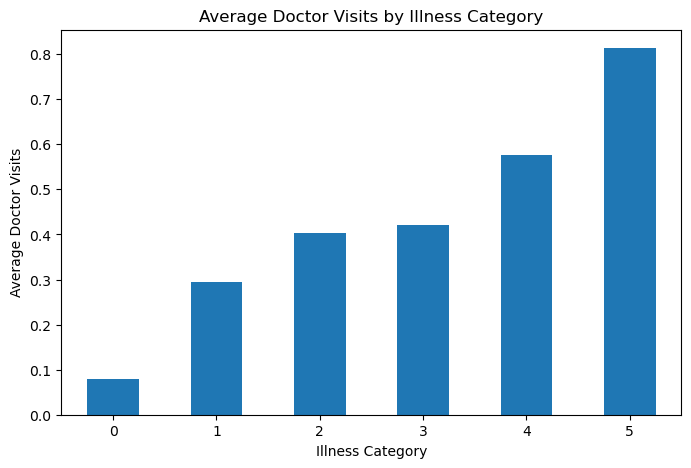

In [40]:
plt.figure(figsize=(8,5))

illness_analysis["mean"].plot(kind="bar")

plt.title("Average Doctor Visits by Illness Category")
plt.xlabel("Illness Category")
plt.ylabel("Average Doctor Visits")
plt.xticks(rotation=0)

plt.show()

In [ ]:
## Interpretation

You can examine whether higher illness categories are associated with greater doctor-visit frequency.

Don't claim causation; this analysis shows association in this dataset.

In [41]:
health_analysis = df.groupby("health")["visits"].agg(
    ["count", "sum", "mean"]
)

health_analysis

,count,sum,mean
health,,,
0,3026,603,0.199273
1,823,276,0.335358
2,446,170,0.381166
3,273,114,0.417582
4,187,100,0.534759
5,132,70,0.530303
6,104,65,0.625000
7,61,56,0.918033
8,42,20,0.476190


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv("1776250375-P2-Healthcare Analytics for Doctor Visits.csv")

In [13]:
df.head()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [14]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 5190
Columns: 13


In [15]:
health_analysis = df.groupby("health")["visits"].agg(
    ["count", "sum", "mean"]
)

health_analysis

,count,sum,mean
health,,,
0,3026,603,0.199273
1,823,276,0.335358
2,446,170,0.381166
3,273,114,0.417582
4,187,100,0.534759
5,132,70,0.530303
6,104,65,0.625000
7,61,56,0.918033
8,42,20,0.476190


In [10]:
health_analysis = df.groupby("health")["visits"].agg(
    ["count", "sum", "mean"]
)

health_analysis

,count,sum,mean
health,,,
0,3026,603,0.199273
1,823,276,0.335358
2,446,170,0.381166
3,273,114,0.417582
4,187,100,0.534759
5,132,70,0.530303
6,104,65,0.625000
7,61,56,0.918033
8,42,20,0.476190


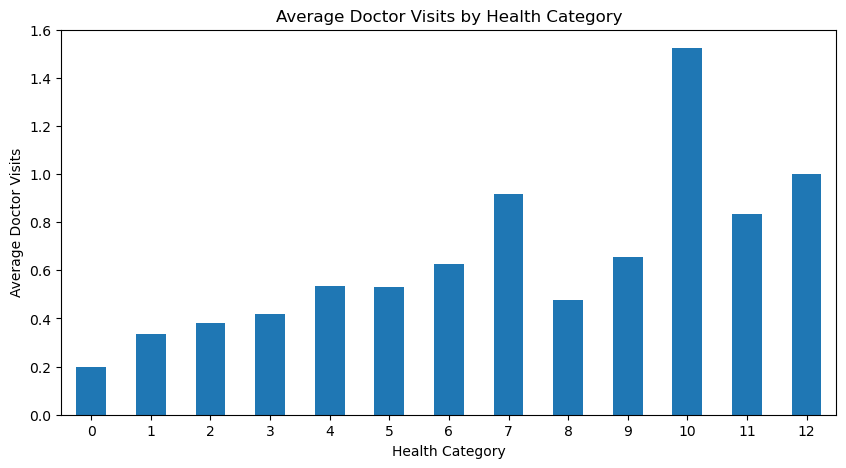

In [16]:
plt.figure(figsize=(10, 5))

health_analysis["mean"].plot(kind="bar")

plt.title("Average Doctor Visits by Health Category")
plt.xlabel("Health Category")
plt.ylabel("Average Doctor Visits")
plt.xticks(rotation=0)

plt.show()

In [ ]:
# Reduced activity analysis

In [17]:
reduced_analysis = df.groupby("reduced")["visits"].mean()

reduced_analysis

reduced
0     0.183880
1     0.355932
2     0.574074
3     1.094595
4     0.800000
5     1.275000
6     1.176471
7     1.184211
8     1.176471
9     1.714286
10    2.000000
11    5.000000
12    2.000000
13    4.000000
14    1.547872
Name: visits, dtype: float64

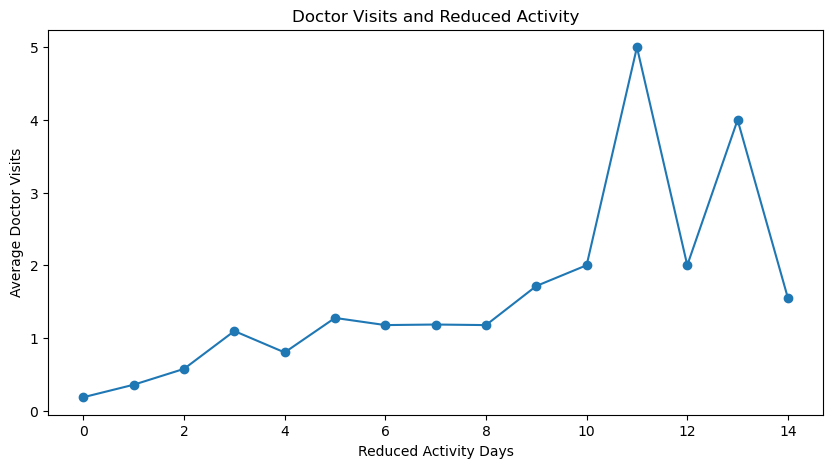

In [18]:
plt.figure(figsize=(10,5))

reduced_analysis.plot(kind="line", marker="o")

plt.title("Doctor Visits and Reduced Activity")
plt.xlabel("Reduced Activity Days")
plt.ylabel("Average Doctor Visits")

plt.show()

In [ ]:
#Private insurance analysis

In [19]:
private_analysis = df.groupby("private")["visits"].agg(
    ["count", "sum", "mean"]
)

private_analysis

,count,sum,mean
private,,,
no,2892,889,0.307400
yes,2298,677,0.294604


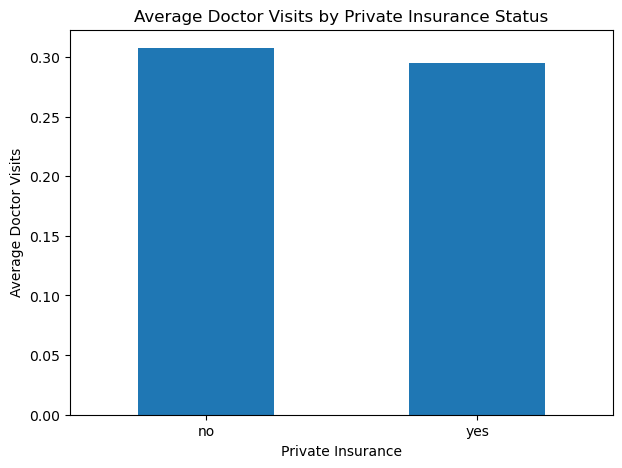

In [20]:
plt.figure(figsize=(7,5))

private_analysis["mean"].plot(kind="bar")

plt.title("Average Doctor Visits by Private Insurance Status")
plt.xlabel("Private Insurance")
plt.ylabel("Average Doctor Visits")
plt.xticks(rotation=0)

plt.show()

In [ ]:
#Free healthcare analysis

In [21]:
freepoor_analysis = df.groupby("freepoor")["visits"].agg(
    ["count", "sum", "mean"]
)

freepoor_analysis

,count,sum,mean
freepoor,,,
no,4968,1531,0.308172
yes,222,35,0.157658


In [22]:
freerepat_analysis = df.groupby("freerepat")["visits"].agg(
    ["count", "sum", "mean"]
)

freerepat_analysis

,count,sum,mean
freerepat,,,
no,4099,1057,0.257868
yes,1091,509,0.466544


In [ ]:
#Chronic conditions

In [23]:
nchronic_analysis = df.groupby("nchronic")["visits"].agg(
    ["count", "sum", "mean"]
)

nchronic_analysis

,count,sum,mean
nchronic,,,
no,3098,843,0.272111
yes,2092,723,0.345602


In [24]:
lchronic_analysis = df.groupby("lchronic")["visits"].agg(
    ["count", "sum", "mean"]
)

lchronic_analysis

,count,sum,mean
lchronic,,,
no,4585,1201,0.261941
yes,605,365,0.603306


In [ ]:
#Compare chronic conditions

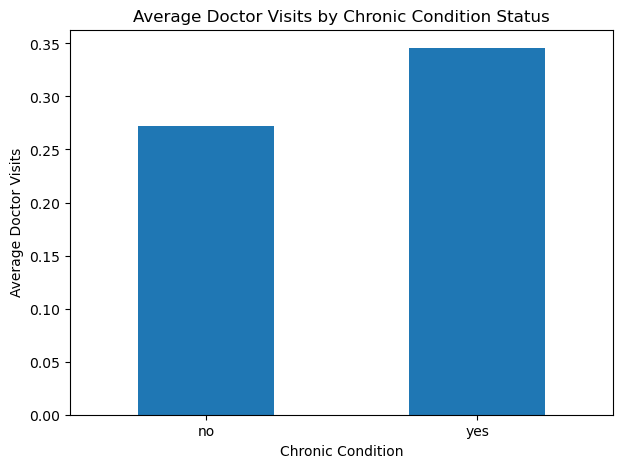

In [25]:
chronic_comparison = df.groupby("nchronic")["visits"].mean()

plt.figure(figsize=(7,5))

chronic_comparison.plot(kind="bar")

plt.title("Average Doctor Visits by Chronic Condition Status")
plt.xlabel("Chronic Condition")
plt.ylabel("Average Doctor Visits")
plt.xticks(rotation=0)

plt.show()

In [ ]:
#Create a correlation matrix

In [26]:
numeric_columns = [
    "visits",
    "age",
    "income",
    "illness",
    "reduced",
    "health"
]

correlation = df[numeric_columns].corr()

correlation

,visits,age,income,illness,reduced,health
visits,1.000000,0.124537,-0.076840,0.223552,0.418954,0.193272
age,0.124537,1.000000,-0.271073,0.204984,0.094745,0.018616
income,-0.076840,-0.271073,1.000000,-0.148812,-0.047545,-0.085790
illness,0.223552,0.204984,-0.148812,1.000000,0.218116,0.360110
reduced,0.418954,0.094745,-0.047545,0.218116,1.000000,0.280208
health,0.193272,0.018616,-0.085790,0.360110,0.280208,1.000000


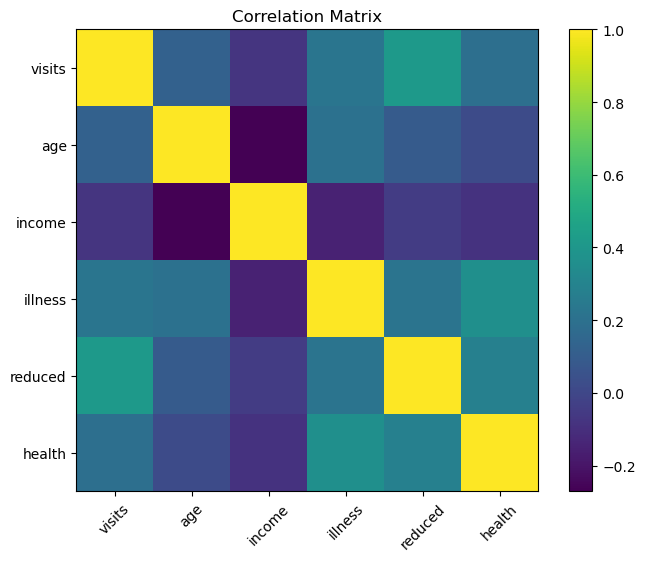

In [27]:
plt.figure(figsize=(8,6))

plt.imshow(correlation, interpolation="nearest")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
##Explanation

Correlation shows the strength and direction of a linear relationship between numerical variables.

It does not prove that one variable causes another.

In [ ]:
#Find the highest average visit categories

In [28]:
df.groupby("illness")["visits"].mean().sort_values(ascending=False)

illness
5    0.813559
4    0.576642
3    0.420664
2    0.403805
1    0.295482
0    0.078507
Name: visits, dtype: float64

In [29]:
df.groupby("health")["visits"].mean().sort_values(ascending=False)

health
10    1.523810
12    1.000000
7     0.918033
11    0.833333
9     0.656250
6     0.625000
4     0.534759
5     0.530303
8     0.476190
3     0.417582
2     0.381166
1     0.335358
0     0.199273
Name: visits, dtype: float64

In [30]:
df.groupby("age")["visits"].mean().sort_values(ascending=False)

age
0.72    0.482968
0.52    0.414414
0.57    0.399267
0.67    0.377778
0.62    0.354430
0.42    0.317460
0.47    0.270718
0.27    0.258126
0.37    0.246575
0.32    0.242525
0.19    0.212766
0.22    0.201154
Name: visits, dtype: float64

In [31]:
df.groupby("income")["visits"].mean().sort_values(ascending=False)

income
0.01    0.485714
0.25    0.420921
0.00    0.367089
0.35    0.359307
0.15    0.349398
0.45    0.305000
1.30    0.277778
1.50    0.265116
0.55    0.252677
0.65    0.246154
0.75    0.244898
0.90    0.207131
0.06    0.200000
1.10    0.177285
Name: visits, dtype: float64

In [ ]:
##This gives you data-backed observations for your final report.

In [ ]:
#Create a KPI section

In [32]:
total_patients = len(df)
total_visits = df["visits"].sum()
average_visits = df["visits"].mean()
patients_with_visits = (df["visits"] > 0).sum()

print("Total Records:", total_patients)
print("Total Doctor Visits:", total_visits)
print("Average Doctor Visits:", round(average_visits, 2))
print("Patients with at least one visit:", patients_with_visits)

Total Records: 5190
Total Doctor Visits: 1566
Average Doctor Visits: 0.3
Patients with at least one visit: 1049


In [ ]:
#Create a summary table

In [33]:
summary = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Total Doctor Visits",
        "Average Doctor Visits",
        "Patients with Doctor Visits"
    ],
    "Value": [
        total_patients,
        total_visits,
        round(average_visits, 2),
        patients_with_visits
    ]
})

summary

,Metric,Value
0,Total Records,5190.0
1,Total Doctor Visits,1566.0
2,Average Doctor Visits,0.3
3,Patients with Doctor Visits,1049.0


In [ ]:
## Key Insights

1. The dataset contains 5,190 healthcare records.
2. Doctor visits are concentrated heavily around zero visits.
3. The average number of doctor visits per record is approximately 0.30.
4. Gender-wise visit patterns can be compared using average visits.
5. Illness categories show differences in average doctor-visit frequency.
6. Health categories can be compared to understand healthcare utilization patterns.
7. Chronic-condition status can be examined for differences in doctor visits.
8. Income and insurance-related categories provide additional dimensions for healthcare utilization analysis.